In [4]:
# Comparison of fragmentation rate constants
# Load and display the data
import pandas as pd
file_path = "../Supporting Information 2_PlasticFADE.xlsx"  # CHECK: confirm file path
sheet_name = "Comparison"
data = pd.read_excel(file_path, sheet_name=sheet_name, usecols='A,G,I:K,W:BG', skiprows=1, nrows=16)
data_frag = data.iloc[0:8, ]
pd.set_option('display.float_format', '{:.2e}'.format)
print(data_frag)

                   Model input  k_literature [d-1]  k_m_LL [d-1]  \
0      N.S., Micro, N.S., Wsur            2.33e-03      6.12e-09   
1      N.S., Micro, N.S., TopS            2.33e-03      5.75e-09   
2      N.S., Micro, N.S., Sedm            2.33e-03      0.00e+00   
3  N.S., 1000 μm, Sphere, WSur            2.74e-02      2.46e-08   
4  N.S., 1000 μm, Sphere, WCol            2.74e-03      8.17e-18   
5  N.S., 1000 μm, Sphere, Sedm            2.74e-03      0.00e+00   
6       PP, Micro, Sphere, N/A            5.48e-05      5.66e-08   
7       PP, Micro, Sphere, N/A            5.10e-06      3.14e-08   

   k_model [d-1]  k_m_UL [d-1]   95_min   95_max  k_all_pp_1  k_all_pp_10  \
0       2.59e-05      4.10e+00 4.50e-11 4.10e+07    1.55e+02     8.56e-01   
1       2.59e-05      2.06e+00 4.10e-11 5.20e+07    1.55e+02     8.53e-01   
2       0.00e+00      0.00e+00 0.00e+00 0.00e+00    0.00e+00     0.00e+00   
3       5.26e-04      4.84e+02 3.40e-08 2.00e+01         NaN          NaN   
4 

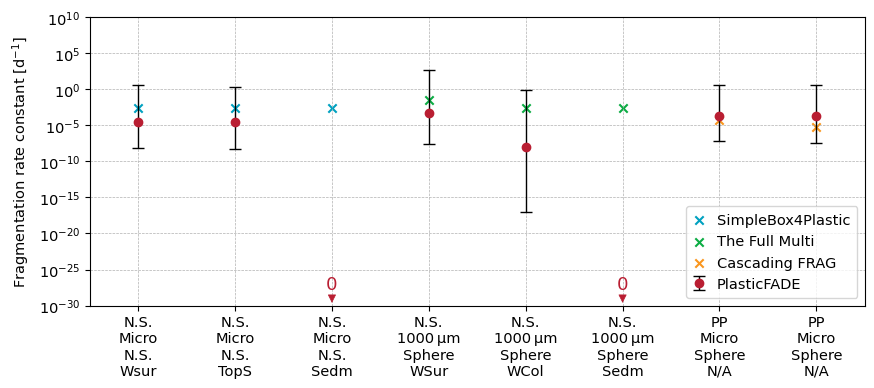

In [6]:
# Plot PlasticFADE outputs together with estimates from existing models (Fragmentation)
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator
import numpy as np

fig, ax = plt.subplots(figsize=(10, 3.75))
x = np.arange(len(data_frag))
y = data_frag['k_model [d-1]']
yerr_lower = y - data_frag['k_m_LL [d-1]']
yerr_upper = data_frag['k_m_UL [d-1]'] - y
yerr = [yerr_lower, yerr_upper]
y1 = data_frag['k_literature [d-1]'].iloc[0:3, ]
y2 = data_frag['k_literature [d-1]'].iloc[3:6, ]
y3 = data_frag['k_literature [d-1]'].iloc[6:8, ]

# Plot k_model with error bars
errorbar_plot = ax.errorbar(x, y, yerr=yerr, fmt='o', color='#B91E32', ecolor='black',
            elinewidth=1, capsize=4, markersize=6, label='PlasticFADE')
# Plot k_literature as blue crosses
h1 = plt.scatter(x[:3], y1, color='#00A1C0', marker='x', label='SimpleBox4Plastic')
h2 = plt.scatter(x[3:6], y2, color='#0BAC43', marker='x', label='The Full Multi')
h3 = plt.scatter(x[-2:], y3, color='#FA961E', marker='x', label='Cascading FRAG')

# Show the outliers ("zero" values)
min_display_y = 1e-30
for i in range(len(data_frag)):
    y_val = y.iloc[i]
    if y_val < min_display_y:
        y_zero_marker = min_display_y * 1  # Position arrow slightly above the bottom limit
        y_zero_label = y_zero_marker * 50  # Adjust the margin between text and arrow
        plt.annotate(
            '0', 
            xy=(i, y_zero_marker),       # Position the arrow tip
            xytext=(i, y_zero_label),  # Position the text above the arrow
            textcoords='data',
            ha='center',
            va='bottom',
            fontsize=13,
            color='#B91E32',
            arrowprops=dict(arrowstyle='-|>', color='#B91E32', lw=0.5),
            clip_on=False
        )

ax.set_xticks(x)
labels = data_frag['Model input'].str.replace(', ', '\n').str.replace(' ', '\u2009')
ax.set_xticklabels(labels)
ax.set_yscale('log')
ax.set_ylabel('Fragmentation rate constant [d$^{-1}$]', labelpad=5, fontsize=10.5)
ax.tick_params(axis='both', which='major', labelsize=10.5)
plt.xlim(-0.5, len(x) - 0.5)  # Pull the first and last data points closer to the edge of the plot
plt.ylim(1e-30, 1e+10)  # Set y-axis limits manually
plt.gca().yaxis.set_major_locator(FixedLocator([10**exp for exp in range(-30, 11, 5)]))  # Manually set the tick positions at every 1e5
plt.grid(True, which="major", ls="--", lw=0.5)

handles = [h1, h2, h3]
all_handles = handles + [errorbar_plot]
ax.legend(handles=all_handles, handlelength=0.8, borderpad=0.5, loc='lower right', fontsize=10.5)
plt.savefig("../Figures/Figure_5a.png", dpi=600, bbox_inches='tight')  # CHECK: confirm name and desired place for the plot
plt.show()

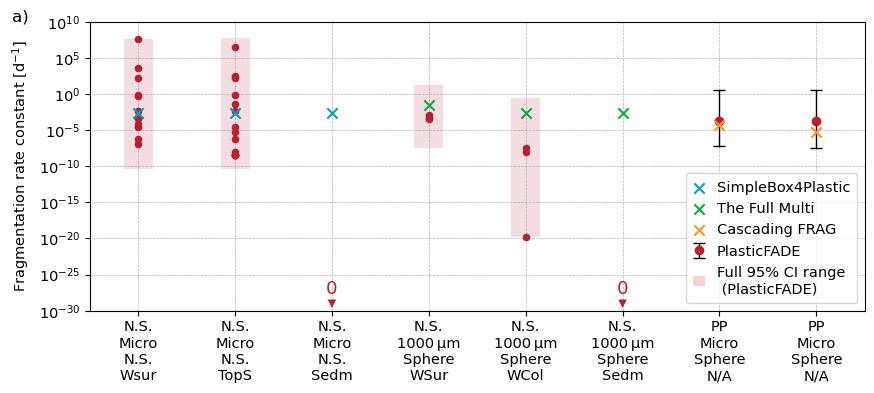

In [7]:
# Plot PlasticFADE outputs together with estimates from existing models (Fragmentation)
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(10, 3.75))
x = np.arange(len(data_frag))
y = data_frag['k_model [d-1]']
yerr_lower = y - data_frag['k_m_LL [d-1]']
yerr_upper = data_frag['k_m_UL [d-1]'] - y
yerr = [yerr_lower, yerr_upper]
y1 = data_frag['k_literature [d-1]'].iloc[0:3, ]
y2 = data_frag['k_literature [d-1]'].iloc[3:6, ]
y3 = data_frag['k_literature [d-1]'].iloc[6:8, ]

# First, plot shaded envelopes for N.S. polymers (so they appear behind the dots)
for i in range(len(data_frag)):
    model_input = data_frag['Model input'].iloc[i]
    
    # Check if it's N.S. polymer and has 95_min/95_max columns
    if model_input.startswith('N.S.'):
        if '95_min' in data_frag.columns and '95_max' in data_frag.columns:
            min_val = data_frag['95_min'].iloc[i]
            max_val = data_frag['95_max'].iloc[i]
            
            # Only plot if values are valid and not NaN
            if not pd.isna(min_val) and not pd.isna(max_val) and min_val > 0 and max_val > 0:
                # Create shaded envelope using fill_between
                # We need a small width for the envelope at this x position
                x_width = 0.3  # Width of the shaded area
                x_left = i - x_width/2
                x_right = i + x_width/2
                
                # Fill the area between min and max
                ax.fill_between([x_left, x_right], min_val, max_val, 
               color='#B91E32', alpha=0.15, zorder=1, edgecolor='none')

# Plot k_model with error bars (only for non-N.S. polymers)
errorbar_plot = None
has_plasticfade = False

for i in range(len(data_frag)):
    model_input = data_frag['Model input'].iloc[i]
    
    # Check if it's N.S. polymer (starts with "N.S.")
    if model_input.startswith('N.S.'):
        # For N.S. polymers, plot all fragmentation values as separate points (no error bars)
        frag_values = []
        
        # Collect all fragmentation columns
        frag_columns = [col for col in data_frag.columns if col.startswith('k_all_')]
        
        for col in frag_columns:
            if col in data_frag.columns and not pd.isna(data_frag[col].iloc[i]):
                val = data_frag[col].iloc[i]
                # Plot if it's not zero (including very small positive numbers)
                if val != 0:
                    frag_values.append(val)
        
        # Plot all fragmentation values as red dots at the same x position
        if frag_values:
            ax.scatter([i] * len(frag_values), frag_values, 
                      color='#B91E32', s=20, marker='o', zorder=3)
            has_plasticfade = True
        
    else:
        # For non-N.S. polymers (like PP, Micro, Sphere, N/A), plot normally with error bars
        if errorbar_plot is None:
            errorbar_plot = ax.errorbar(i, y.iloc[i], yerr=[[yerr_lower.iloc[i]], [yerr_upper.iloc[i]]], 
                                       fmt='o', color='#B91E32', ecolor='black',
                                       elinewidth=1, capsize=4, markersize=6, 
                                       label='PlasticFADE')
            has_plasticfade = True
        else:
            ax.errorbar(i, y.iloc[i], yerr=[[yerr_lower.iloc[i]], [yerr_upper.iloc[i]]], 
                       fmt='o', color='#B91E32', ecolor='black',
                       elinewidth=1, capsize=4, markersize=6)

# Plot k_literature as blue crosses
h1 = plt.scatter(x[:3], y1, color='#00A1C0', marker='x', label='SimpleBox4Plastic', zorder=5, s=55)
h2 = plt.scatter(x[3:6], y2, color='#0BAC43', marker='x', label='The Full Multi', zorder=5, s=55)
h3 = plt.scatter(x[-2:], y3, color='#FA961E', marker='x', label='Cascading FRAG', zorder=5, s=55)

# Show the outliers ("zero" values)
min_display_y = 1e-30
for i in range(len(data_frag)):
    y_val = y.iloc[i]
    if y_val < min_display_y:
        y_zero_marker = min_display_y * 1  # Position arrow slightly above the bottom limit
        y_zero_label = y_zero_marker * 50  # Adjust the margin between text and arrow
        plt.annotate(
            '0', 
            xy=(i, y_zero_marker),       # Position the arrow tip
            xytext=(i, y_zero_label),  # Position the text above the arrow
            textcoords='data',
            ha='center',
            va='bottom',
            fontsize=13,
            color='#B91E32',
            arrowprops=dict(arrowstyle='-|>', color='#B91E32', lw=0.5),
            clip_on=False
        )

ax.set_xticks(x)
labels = data_frag['Model input'].str.replace(', ', '\n').str.replace(' ', '\u2009')
ax.set_xticklabels(labels)
ax.set_yscale('log')
ax.set_ylabel('Fragmentation rate constant [d$^{-1}$]', labelpad=5, fontsize=10.5)
ax.tick_params(axis='both', which='major', labelsize=10.5)
plt.xlim(-0.5, len(x) - 0.5)  # Pull the first and last data points closer to the edge of the plot
plt.ylim(1e-30, 1e+10)  # Set y-axis limits manually
plt.gca().yaxis.set_major_locator(FixedLocator([10**exp for exp in range(-30, 11, 5)]))  # Manually set the tick positions at every 1e5
plt.grid(True, which="major", ls="--", lw=0.5)

# Create legend
handles = [h1, h2, h3]
if has_plasticfade:
    # If we have PlasticFADE points but no errorbar_plot (all N.S.), create a dummy for the legend
    if errorbar_plot is None:
        # Create a dummy for the shaded envelope in legend
        from matplotlib.patches import Patch
        dummy_errorbar = ax.errorbar([], [], fmt='o', color='#B91E32', ecolor='black',
                                     elinewidth=1, capsize=4, markersize=6, label='PlasticFADE')
        # Add shaded envelope to legend
        dummy_patch = Patch(facecolor='#B91E32', alpha=0.2, label='Full 95% CI range\n (PlasticFADE)')
        all_handles = handles + [dummy_errorbar, dummy_patch]
    else:
        # Add shaded envelope patch to legend
        from matplotlib.patches import Patch
        dummy_patch = Patch(facecolor='#B91E32', alpha=0.2, label='Full 95% CI range\n (PlasticFADE)')
        all_handles = handles + [errorbar_plot, dummy_patch]
else:
    all_handles = handles
    
ax.legend(handles=all_handles, handlelength=0.8, borderpad=0.5, loc='lower right', fontsize=10.5)
plt.text(-0.1, 1.0, "a)", transform=plt.gca().transAxes, fontsize=12, fontweight='normal')
plt.savefig("../Figures/Figure_5a.png", dpi=600, bbox_inches='tight')
plt.show()

In [8]:
# Comparison of degradation rate constants
# Load and display the data
data_degr = data.iloc[8:16, ]
pd.set_option('display.float_format', '{:.2e}'.format)
print(data_degr)

                    Model input  k_literature [d-1]  k_m_LL [d-1]  \
8       N.S., Micro, N.S., WSur            8.64e-06      2.40e-04   
9       N.S., Micro, N.S., TopS            2.59e-06      1.46e-04   
10      N.S., Micro, N.S., Sedm            2.59e-06      9.74e-06   
11  N.S., 1000 μm, Sphere, WSur            1.39e-04      2.42e-04   
12  N.S., 1000 μm, Sphere, WCol            1.39e-04      3.92e-06   
13  N.S., 1000 μm, Sphere, Sedm            1.39e-04      1.00e-05   
14        PP, 375 μm, Film, Air            1.20e-05      2.14e-04   
15        PE, 375 μm, Film, Air            7.95e-05      3.91e-05   

    k_model [d-1]  k_m_UL [d-1]   95_min   95_max  k_all_pp_1  k_all_pp_10  \
8        5.32e-04      3.13e-03 4.85e-06 3.69e+00    5.85e-04     5.67e-04   
9        7.70e-04      6.99e-03 3.98e-06 6.44e+00    8.46e-04     8.20e-04   
10       3.06e-05      1.24e-04 3.58e-08 3.65e+00    3.36e-05     3.26e-05   
11       5.32e-04      2.99e-03 4.25e-05 2.99e-03         NaN     

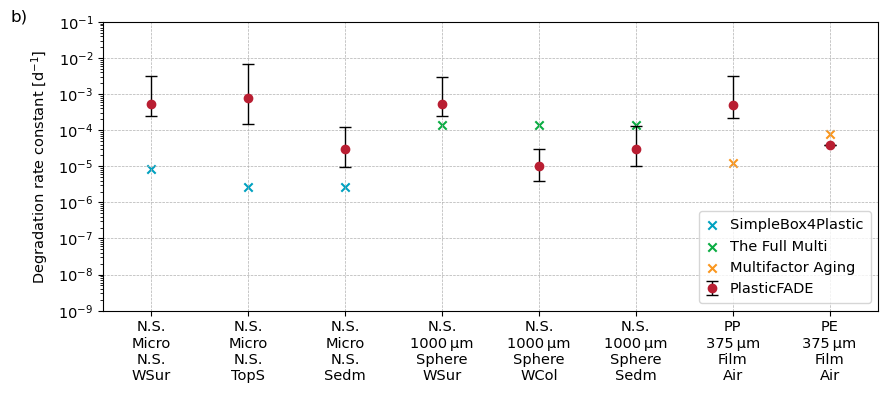

In [9]:
# Plot PlasticFADE outputs together with estimates from existing models (Degradation)
fig, ax = plt.subplots(figsize=(10, 3.75))
x = np.arange(len(data_frag))
y = data_degr['k_model [d-1]']
yerr_lower = y - data_degr['k_m_LL [d-1]']
yerr_upper = data_degr['k_m_UL [d-1]'] - y
yerr = [yerr_lower, yerr_upper]
y1 = data_degr['k_literature [d-1]'].iloc[0:3, ]
y2 = data_degr['k_literature [d-1]'].iloc[3:6, ]
y3 = data_degr['k_literature [d-1]'].iloc[6:8, ]

# Plot k_model with error bars
errorbar_plot = ax.errorbar(x, y, yerr=yerr, fmt='o', color='#B91E32', ecolor='black',
            elinewidth=1, capsize=4, markersize=6, label='PlasticFADE')
# Plot k_literature as blue crosses
h1 = plt.scatter(x[:3], y1, color='#00A1C0', marker='x', label='SimpleBox4Plastic')
h2 = plt.scatter(x[3:6], y2, color='#0BAC43', marker='x', label='The Full Multi')
h3 = plt.scatter(x[-2:], y3, color='#FA961E', marker='x', label='Multifactor Aging')

ax.set_xticks(x)
labels = data_degr['Model input'].str.replace(', ', '\n').str.replace(' ', '\u2009')
ax.set_xticklabels(labels)
ax.set_yscale('log')
ax.set_ylabel('Degradation rate constant [d$^{-1}$]', labelpad=5, fontsize=10.5)
ax.tick_params(axis='both', which='major', labelsize=10.5)
plt.xlim(-0.5, len(x) - 0.5)  # Pull the first and last data points closer to the edge of the plot
plt.ylim(1e-9, 1e-1)  # Set y-axis limits manually
plt.grid(True, which="major", ls="--", lw=0.5)

handles = [h1, h2, h3]
all_handles = handles + [errorbar_plot]
ax.legend(handles=all_handles, handlelength=0.8, borderpad=0.5, loc='lower right', fontsize=10.5)
plt.text(-0.12, 1.0, "b)", transform=plt.gca().transAxes, fontsize=12, fontweight='normal')
plt.savefig("../Figures/Figure_5b.png", dpi=600, bbox_inches='tight')  # CHECK: confirm name and desired place for the plot
plt.show()

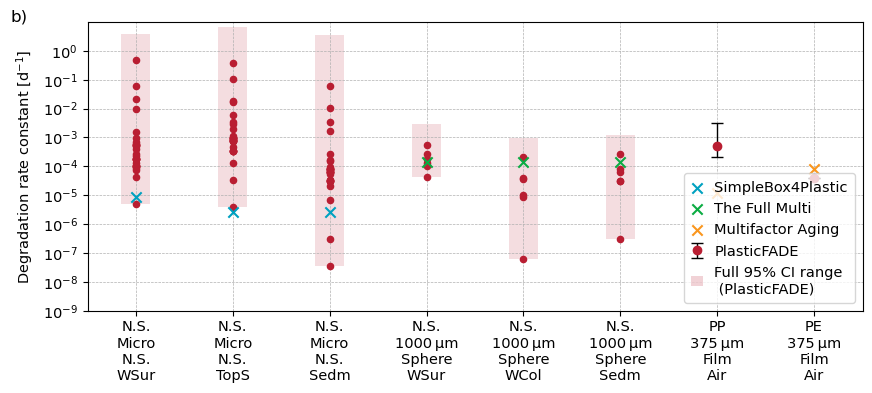

In [10]:
# Plot PlasticFADE outputs together with estimates from existing models (Degradation)
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator
import numpy as np
import pandas as pd

fig, ax = plt.subplots(figsize=(10, 3.75))
x = np.arange(len(data_degr))
y = data_degr['k_model [d-1]']
yerr_lower = y - data_degr['k_m_LL [d-1]']
yerr_upper = data_degr['k_m_UL [d-1]'] - y
yerr = [yerr_lower, yerr_upper]
y1 = data_degr['k_literature [d-1]'].iloc[0:3, ]
y2 = data_degr['k_literature [d-1]'].iloc[3:6, ]
y3 = data_degr['k_literature [d-1]'].iloc[6:8, ]

# First, plot shaded envelopes for N.S. polymers (so they appear behind the dots)
for i in range(len(data_degr)):
    model_input = data_degr['Model input'].iloc[i]
    
    # Check if it's N.S. polymer and has 95_min/95_max columns
    if model_input.startswith('N.S.'):
        if '95_min' in data_degr.columns and '95_max' in data_degr.columns:
            min_val = data_degr['95_min'].iloc[i]
            max_val = data_degr['95_max'].iloc[i]
            
            # Only plot if values are valid and not NaN
            if not pd.isna(min_val) and not pd.isna(max_val) and min_val > 0 and max_val > 0:
                # Create shaded envelope using fill_between
                x_width = 0.3  # Width of the shaded area
                x_left = i - x_width/2
                x_right = i + x_width/2
                
                # Fill the area between min and max
                ax.fill_between([x_left, x_right], min_val, max_val, 
                               color='#B91E32', alpha=0.15, zorder=1, edgecolor='none')

# Plot k_model with error bars (only for non-N.S. polymers)
errorbar_plot = None
has_plasticfade = False

for i in range(len(data_degr)):
    model_input = data_degr['Model input'].iloc[i]
    
    # Check if it's N.S. polymer (starts with "N.S.")
    if model_input.startswith('N.S.'):
        # For N.S. polymers, plot all degradation values as separate points (no error bars)
        deg_values = []
        
        # Collect all degradation columns (k_all_)
        deg_columns = [col for col in data_degr.columns if col.startswith('k_all_')]
        
        for col in deg_columns:
            if col in data_degr.columns and not pd.isna(data_degr[col].iloc[i]):
                val = data_degr[col].iloc[i]
                # Plot if it's not zero (including very small positive numbers)
                if val != 0:
                    deg_values.append(val)
        
        # Plot all degradation values as red dots at the same x position
        if deg_values:
            ax.scatter([i] * len(deg_values), deg_values, 
                      color='#B91E32', s=20, marker='o', zorder=3)
            has_plasticfade = True
        
    else:
        # For non-N.S. polymers (like PP, Micro, Sphere, N/A), plot normally with error bars
        if errorbar_plot is None:
            errorbar_plot = ax.errorbar(i, y.iloc[i], yerr=[[yerr_lower.iloc[i]], [yerr_upper.iloc[i]]], 
                                       fmt='o', color='#B91E32', ecolor='black',
                                       elinewidth=1, capsize=4, markersize=6, 
                                       label='PlasticFADE')
            has_plasticfade = True
        else:
            ax.errorbar(i, y.iloc[i], yerr=[[yerr_lower.iloc[i]], [yerr_upper.iloc[i]]], 
                       fmt='o', color='#B91E32', ecolor='black',
                       elinewidth=1, capsize=4, markersize=6)

# Plot k_literature as crosses
h1 = plt.scatter(x[:3], y1, color='#00A1C0', marker='x', label='SimpleBox4Plastic', zorder=5, s=55)
h2 = plt.scatter(x[3:6], y2, color='#0BAC43', marker='x', label='The Full Multi', zorder=5, s=55)
h3 = plt.scatter(x[-2:], y3, color='#FA961E', marker='x', label='Multifactor Aging', zorder=5, s=55)

# Show the outliers ("zero" values)
min_display_y = 1e-9
for i in range(len(data_degr)):
    y_val = y.iloc[i]
    if y_val < min_display_y:
        y_zero_marker = min_display_y * 1  # Position arrow slightly above the bottom limit
        y_zero_label = y_zero_marker * 50  # Adjust the margin between text and arrow
        plt.annotate(
            '0', 
            xy=(i, y_zero_marker),       # Position the arrow tip
            xytext=(i, y_zero_label),  # Position the text above the arrow
            textcoords='data',
            ha='center',
            va='bottom',
            fontsize=13,
            color='#B91E32',
            arrowprops=dict(arrowstyle='-|>', color='#B91E32', lw=0.5),
            clip_on=False
        )

ax.set_xticks(x)
labels = data_degr['Model input'].str.replace(', ', '\n').str.replace(' ', '\u2009')
ax.set_xticklabels(labels)
ax.set_yscale('log')
ax.set_ylabel('Degradation rate constant [d$^{-1}$]', labelpad=5, fontsize=10.5)
ax.tick_params(axis='both', which='major', labelsize=10.5)
plt.xlim(-0.5, len(x) - 0.5)
plt.ylim(1e-9, 1e+1)
plt.gca().yaxis.set_major_locator(FixedLocator([10**exp for exp in range(-9, +1, 1)]))
plt.grid(True, which="major", ls="--", lw=0.5)

# Create legend
handles = [h1, h2, h3]
if has_plasticfade:
    if errorbar_plot is None:
        from matplotlib.patches import Patch
        dummy_errorbar = ax.errorbar([], [], fmt='o', color='#B91E32', ecolor='black',
                                     elinewidth=1, capsize=4, markersize=6, label='PlasticFADE')
        dummy_patch = Patch(facecolor='#B91E32', alpha=0.2, label='Full 95% CI range\n (PlasticFADE)')
        all_handles = handles + [dummy_errorbar, dummy_patch]
    else:
        from matplotlib.patches import Patch
        dummy_patch = Patch(facecolor='#B91E32', alpha=0.2, label='Full 95% CI range\n (PlasticFADE)')
        all_handles = handles + [errorbar_plot, dummy_patch]
else:
    all_handles = handles
    
ax.legend(handles=all_handles, handlelength=0.8, borderpad=0.5, loc='lower right', fontsize=10.5)
plt.text(-0.1, 1.0, "b)", transform=plt.gca().transAxes, fontsize=12, fontweight='normal')
plt.savefig("../Figures/Figure_5b.png", dpi=600, bbox_inches='tight')
plt.show()

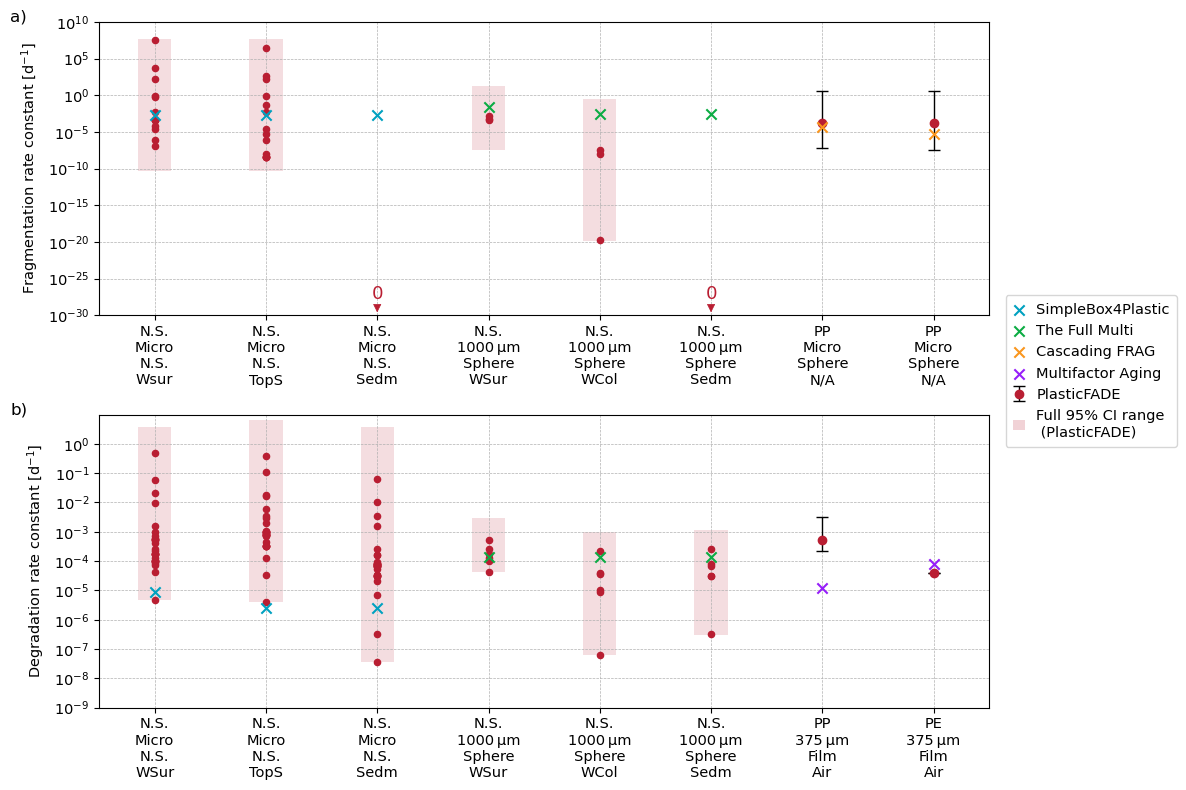

In [23]:
# Plot PlasticFADE outputs together with estimates from existing models (Fragmentation & Degradation)
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator
import numpy as np
import pandas as pd

# Create figure with two subplots stacked vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# =============================================
# TOP SUBPLOT: Fragmentation
# =============================================
x1 = np.arange(len(data_frag))
y_frag = data_frag['k_model [d-1]']
yerr_lower_frag = y_frag - data_frag['k_m_LL [d-1]']
yerr_upper_frag = data_frag['k_m_UL [d-1]'] - y_frag
y1_frag = data_frag['k_literature [d-1]'].iloc[0:3, ]
y2_frag = data_frag['k_literature [d-1]'].iloc[3:6, ]
y3_frag = data_frag['k_literature [d-1]'].iloc[6:8, ]

# Shaded envelopes for N.S. polymers
for i in range(len(data_frag)):
    model_input = data_frag['Model input'].iloc[i]
    if model_input.startswith('N.S.'):
        if '95_min' in data_frag.columns and '95_max' in data_frag.columns:
            min_val = data_frag['95_min'].iloc[i]
            max_val = data_frag['95_max'].iloc[i]
            if not pd.isna(min_val) and not pd.isna(max_val) and min_val > 0 and max_val > 0:
                x_width = 0.3
                x_left = i - x_width/2
                x_right = i + x_width/2
                ax1.fill_between([x_left, x_right], min_val, max_val, 
                               color='#B91E32', alpha=0.15, zorder=1, edgecolor='none')

# Plot k_model with error bars
errorbar_plot_frag = None
has_plasticfade_frag = False

for i in range(len(data_frag)):
    model_input = data_frag['Model input'].iloc[i]
    if model_input.startswith('N.S.'):
        frag_values = []
        frag_columns = [col for col in data_frag.columns if col.startswith('k_all_')]
        for col in frag_columns:
            if col in data_frag.columns and not pd.isna(data_frag[col].iloc[i]):
                val = data_frag[col].iloc[i]
                if val != 0:
                    frag_values.append(val)
        if frag_values:
            ax1.scatter([i] * len(frag_values), frag_values, 
                      color='#B91E32', s=20, marker='o', zorder=3)
            has_plasticfade_frag = True
    else:
        if errorbar_plot_frag is None:
            errorbar_plot_frag = ax1.errorbar(i, y_frag.iloc[i], yerr=[[yerr_lower_frag.iloc[i]], [yerr_upper_frag.iloc[i]]], 
                                       fmt='o', color='#B91E32', ecolor='black',
                                       elinewidth=1, capsize=4, markersize=6, 
                                       label='PlasticFADE')
            has_plasticfade_frag = True
        else:
            ax1.errorbar(i, y_frag.iloc[i], yerr=[[yerr_lower_frag.iloc[i]], [yerr_upper_frag.iloc[i]]], 
                       fmt='o', color='#B91E32', ecolor='black',
                       elinewidth=1, capsize=4, markersize=6)

# Plot k_literature as crosses
h1_frag = ax1.scatter(x1[:3], y1_frag, color='#00A1C0', marker='x', label='SimpleBox4Plastic', zorder=5, s=55)
h2_frag = ax1.scatter(x1[3:6], y2_frag, color='#0BAC43', marker='x', label='The Full Multi', zorder=5, s=55)
h3_frag = ax1.scatter(x1[-2:], y3_frag, color='#FA961E', marker='x', label='Cascading FRAG', zorder=5, s=55)

# Zero value annotations
min_display_y_frag = 1e-30
for i in range(len(data_frag)):
    y_val = y_frag.iloc[i]
    if y_val < min_display_y_frag:
        y_zero_marker = min_display_y_frag * 1
        y_zero_label = y_zero_marker * 50
        ax1.annotate('0', xy=(i, y_zero_marker), xytext=(i, y_zero_label),
                    textcoords='data', ha='center', va='bottom',
                    fontsize=13, color='#B91E32',
                    arrowprops=dict(arrowstyle='-|>', color='#B91E32', lw=0.5),
                    clip_on=False)

ax1.set_xticks(x1)
labels_frag = data_frag['Model input'].str.replace(', ', '\n').str.replace(' ', '\u2009')
ax1.set_xticklabels(labels_frag)
ax1.set_yscale('log')
ax1.set_ylabel('Fragmentation rate constant [d$^{-1}$]', labelpad=5, fontsize=10.5)
ax1.tick_params(axis='both', which='major', labelsize=10.5)
ax1.set_xlim(-0.5, len(x1) - 0.5)
ax1.set_ylim(1e-30, 1e+10)
ax1.yaxis.set_major_locator(FixedLocator([10**exp for exp in range(-30, 11, 5)]))
ax1.grid(True, which="major", ls="--", lw=0.5)

# Legend for top subplot
handles_frag = [h1_frag, h2_frag, h3_frag]
if has_plasticfade_frag:
    if errorbar_plot_frag is None:
        from matplotlib.patches import Patch
        dummy_errorbar = ax1.errorbar([], [], fmt='o', color='#B91E32', ecolor='black',
                                     elinewidth=1, capsize=4, markersize=6, label='PlasticFADE')
        dummy_patch = Patch(facecolor='#B91E32', alpha=0.2, label='Full 95% CI range\n (PlasticFADE)')
        all_handles_frag = handles_frag + [dummy_errorbar, dummy_patch]
    else:
        from matplotlib.patches import Patch
        dummy_patch = Patch(facecolor='#B91E32', alpha=0.2, label='Full 95% CI range\n (PlasticFADE)')
        all_handles_frag = handles_frag + [errorbar_plot_frag, dummy_patch]
else:
    all_handles_frag = handles_frag

#ax1.legend(handles=all_handles_frag, handlelength=0.8, borderpad=0.5, loc='lower right', fontsize=10.5)
ax1.text(-0.1, 1.0, "a)", transform=ax1.transAxes, fontsize=12, fontweight='normal')

# =============================================
# BOTTOM SUBPLOT: Degradation
# =============================================
x2 = np.arange(len(data_degr))
y_degr = data_degr['k_model [d-1]']
yerr_lower_degr = y_degr - data_degr['k_m_LL [d-1]']
yerr_upper_degr = data_degr['k_m_UL [d-1]'] - y_degr
y1_degr = data_degr['k_literature [d-1]'].iloc[0:3, ]
y2_degr = data_degr['k_literature [d-1]'].iloc[3:6, ]
y3_degr = data_degr['k_literature [d-1]'].iloc[6:8, ]

# Shaded envelopes for N.S. polymers
for i in range(len(data_degr)):
    model_input = data_degr['Model input'].iloc[i]
    if model_input.startswith('N.S.'):
        if '95_min' in data_degr.columns and '95_max' in data_degr.columns:
            min_val = data_degr['95_min'].iloc[i]
            max_val = data_degr['95_max'].iloc[i]
            if not pd.isna(min_val) and not pd.isna(max_val) and min_val > 0 and max_val > 0:
                x_width = 0.3
                x_left = i - x_width/2
                x_right = i + x_width/2
                ax2.fill_between([x_left, x_right], min_val, max_val, 
                               color='#B91E32', alpha=0.15, zorder=1, edgecolor='none')

# Plot k_model with error bars
errorbar_plot_degr = None
has_plasticfade_degr = False

for i in range(len(data_degr)):
    model_input = data_degr['Model input'].iloc[i]
    if model_input.startswith('N.S.'):
        deg_values = []
        deg_columns = [col for col in data_degr.columns if col.startswith('k_all_')]
        for col in deg_columns:
            if col in data_degr.columns and not pd.isna(data_degr[col].iloc[i]):
                val = data_degr[col].iloc[i]
                if val != 0:
                    deg_values.append(val)
        if deg_values:
            ax2.scatter([i] * len(deg_values), deg_values, 
                      color='#B91E32', s=20, marker='o', zorder=3)
            has_plasticfade_degr = True
    else:
        if errorbar_plot_degr is None:
            errorbar_plot_degr = ax2.errorbar(i, y_degr.iloc[i], yerr=[[yerr_lower_degr.iloc[i]], [yerr_upper_degr.iloc[i]]], 
                                       fmt='o', color='#B91E32', ecolor='black',
                                       elinewidth=1, capsize=4, markersize=6, 
                                       label='PlasticFADE')
            has_plasticfade_degr = True
        else:
            ax2.errorbar(i, y_degr.iloc[i], yerr=[[yerr_lower_degr.iloc[i]], [yerr_upper_degr.iloc[i]]], 
                       fmt='o', color='#B91E32', ecolor='black',
                       elinewidth=1, capsize=4, markersize=6)

# Plot k_literature as crosses
h1_degr = ax2.scatter(x2[:3], y1_degr, color='#00A1C0', marker='x', label='SimpleBox4Plastic', zorder=5, s=55)
h2_degr = ax2.scatter(x2[3:6], y2_degr, color='#0BAC43', marker='x', label='The Full Multi', zorder=5, s=55)
h3_degr = ax2.scatter(x2[-2:], y3_degr, color='#961efa', marker='x', label='Multifactor Aging', zorder=5, s=55)

# Zero value annotations
min_display_y_degr = 1e-9
for i in range(len(data_degr)):
    y_val = y_degr.iloc[i]
    if y_val < min_display_y_degr:
        y_zero_marker = min_display_y_degr * 1
        y_zero_label = y_zero_marker * 50
        ax2.annotate('0', xy=(i, y_zero_marker), xytext=(i, y_zero_label),
                    textcoords='data', ha='center', va='bottom',
                    fontsize=13, color='#B91E32',
                    arrowprops=dict(arrowstyle='-|>', color='#B91E32', lw=0.5),
                    clip_on=False)

ax2.set_xticks(x2)
labels_degr = data_degr['Model input'].str.replace(', ', '\n').str.replace(' ', '\u2009')
ax2.set_xticklabels(labels_degr)
ax2.set_yscale('log')
ax2.set_ylabel('Degradation rate constant [d$^{-1}$]', labelpad=5, fontsize=10.5)
ax2.tick_params(axis='both', which='major', labelsize=10.5)
ax2.set_xlim(-0.5, len(x2) - 0.5)
ax2.set_ylim(1e-9, 1e+1)
ax2.yaxis.set_major_locator(FixedLocator([10**exp for exp in range(-9, 1, 1)]))
ax2.grid(True, which="major", ls="--", lw=0.5)

# Legend for bottom subplot
handles_degr = [h1_degr, h2_degr, h3_degr]
if has_plasticfade_degr:
    if errorbar_plot_degr is None:
        from matplotlib.patches import Patch
        dummy_errorbar = ax2.errorbar([], [], fmt='o', color='#B91E32', ecolor='black',
                                     elinewidth=1, capsize=4, markersize=6, label='PlasticFADE')
        dummy_patch = Patch(facecolor='#B91E32', alpha=0.2, label='Full 95% CI range\n (PlasticFADE)')
        all_handles_degr = handles_degr + [dummy_errorbar, dummy_patch]
    else:
        from matplotlib.patches import Patch
        dummy_patch = Patch(facecolor='#B91E32', alpha=0.2, label='Full 95% CI range\n (PlasticFADE)')
        all_handles_degr = handles_degr + [errorbar_plot_degr, dummy_patch]
else:
    all_handles_degr = handles_degr

#ax2.legend(handles=all_handles_degr, handlelength=0.8, borderpad=0.5, loc='lower right', fontsize=10.5)
ax2.text(-0.1, 1.0, "b)", transform=ax2.transAxes, fontsize=12, fontweight='normal')
# Define custom order for legend
custom_order = [
    h1_frag,   # SimpleBox4Plastic
    h2_frag,   # The Full Multi
    h3_frag,   # Cascading FRAG
    h3_degr,   # Multifactor Aging
    errorbar_plot_frag,  # PlasticFADE (point)
    dummy_patch          # PlasticFADE (95% CI)
]

fig.legend(handles=custom_order, handlelength=0.8, borderpad=0.5, loc='center right', fontsize=10.5, bbox_to_anchor=(1.18, 0.53))
# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig("../Figures/Figure_5_combined.png", dpi=600, bbox_inches='tight')
plt.show()